#### Importação das Bibliotecas

In [1]:
# pandas para limpeza e análise dos dados
import pandas as pd

# numpy para cálculos e processamento de dados numéricos
import numpy as np   

# matplotlib.pyplot para gerar visualizações
import matplotlib.pyplot as plt

# seaborn também para visualizações 
import seaborn as sns

# ticker para personalizar os marcadores nos eixos dos gráficos
import matplotlib.ticker as mtick


#### Carregamento e Visão Geral da Base

In [2]:
# carregando da base de dados
df = pd.read_excel('data_base.xlsx')

# visualizando as primeiras linhas da base
df.head()

,id,credit_approval,closed_at,state,monthly_income,loan_term,credit_score,property_value,loan_amount,property_type,customer_age,reason,channel,profession_type
0,1,2024-01-18,NaT,SP,7000.0,NaN,NaN,700000,120000.0,apartment,47,debts_refinancing,offline,businessman
1,2,2024-08-19,2024-09-30,SP,7753.0,NaN,NaN,1500000,140000.0,house,45,debts_payment,organic,freelancer
2,3,2024-07-28,NaT,SP,30000.0,NaN,NaN,200000,108000.0,apartment,44,investment_in_own_business,organic,clt
3,4,2024-10-11,NaT,SP,20000.0,NaN,NaN,800000,150000.0,apartment,58,debts_payment,organic,businessman
4,5,2025-07-20,2025-09-15,SP,9000.0,NaN,NaN,600000,140000.0,house,57,investment_in_own_business,offline,businessman


In [3]:
# verificando quantidade de linhas e colunas
df.shape

(1185, 14)

In [4]:
# listando os nomes das colunas 
df.columns.tolist()

['id',
 'credit_approval',
 'closed_at',
 'state',
 'monthly_income',
 'loan_term',
 'credit_score',
 'property_value',
 'loan_amount',
 'property_type',
 'customer_age',
 'reason',
 'channel',
 'profession_type']

In [5]:
# informações gerais da base
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1185 entries, 0 to 1184
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   id               1185 non-null   int64         
 1   credit_approval  1185 non-null   datetime64[ns]
 2   closed_at        378 non-null    datetime64[ns]
 3   state            1166 non-null   object        
 4   monthly_income   1185 non-null   float64       
 5   loan_term        699 non-null    float64       
 6   credit_score     694 non-null    float64       
 7   property_value   1185 non-null   int64         
 8   loan_amount      1183 non-null   float64       
 9   property_type    1174 non-null   object        
 10  customer_age     1185 non-null   int64         
 11  reason           1179 non-null   object        
 12  channel          1183 non-null   object        
 13  profession_type  1178 non-null   object        
dtypes: datetime64[ns](2), float64(4), int64(

In [6]:
# estatísticas descritivas das variáveis numéricas
pd.set_option('display.float_format', '{:.2f}'.format)
df.describe()

,id,credit_approval,closed_at,monthly_income,loan_term,credit_score,property_value,loan_amount,customer_age
count,1185.00,1185,378,1185.00,699.00,694.00,1185.00,1183.00,1185.00
mean,593.00,2025-07-13 10:16:03.147679232,2025-07-23 14:05:42.857142784,16557.03,158.76,605.99,619883.37,168711.22,49.28
min,1.00,2023-09-05 12:00:00,2024-07-01 00:00:00,3000.00,60.00,12.00,42000.00,30000.00,9.00
25%,297.00,2025-04-27 00:00:00,2025-03-20 06:00:00,7000.00,120.00,397.00,300000.00,60000.00,41.00
50%,593.00,2025-08-07 00:00:00,2025-08-30 00:00:00,11000.00,180.00,584.00,450000.00,100000.00,49.00
75%,889.00,2025-10-26 00:00:00,2025-11-30 00:00:00,19000.00,180.00,837.75,700000.00,200000.00,57.00
max,1185.00,2026-03-28 00:00:00,2026-03-28 00:00:00,1020000.00,180.00,1000.00,8000000.00,2000000.00,77.00
std,342.22,NaN,NaN,33948.09,33.73,246.31,626162.41,212223.76,10.45


In [7]:
# verificando os valores existentes em cada variável categórica
colunas_categoricas = df.select_dtypes(include = ['object', 'category']).columns

colunas_categoricas.tolist()
for coluna in colunas_categoricas:
    print(f"\n{'='*50}")
    print(f"VARIÁVEL: {coluna}")
    print(f"{'='*50}")
    print(df[coluna].unique())


VARIÁVEL: state
['SP' 'MG' 'SC' 'PR' 'CE' 'RS' 'MS' 'DF' 'RJ' 'ES' 'TO' 'BA' 'GO' 'PI'
 'PE' 'AL' 'MT' 'MA' 'PB' 'AP' nan 'RO' 'AM' 'SE' 'PA' 'RN']

VARIÁVEL: property_type
['apartment' 'house' 'Commercial' nan 'commercial' 'land' 'apto'
 'Apartment' 'HOUSE' 'Casa' 'Apartamento' 'casa' 'APARTMENT']

VARIÁVEL: reason
['debts_refinancing' 'debts_payment' 'investment_in_own_business' 'others'
 nan 'real_estate_renovation' 'goods_acquisition']

VARIÁVEL: channel
['offline' 'organic' 'other' 'social_media' 'remarketing' 'affiliates' nan]

VARIÁVEL: profession_type
['businessman' 'freelancer' 'clt' 'retired' 'public_employee'
 'self_employed' 'other' nan]


In [8]:
# quantidade de valores únicos por variável
df.nunique().sort_values(ascending=False)

id                 1185
credit_score        392
credit_approval     337
closed_at           228
monthly_income      222
property_value      118
loan_amount         114
customer_age         55
state                25
property_type        12
profession_type       7
reason                6
channel               6
loan_term             5
dtype: int64

#### Verificação de Inconsistências

In [9]:
# percentual de valores ausentes por variável 
ausentes = pd.DataFrame({
    'quantidade_nulos': df.isna().sum(),
    'percentual_nulos': df.isna().mean() * 100
})

ausentes.sort_values('percentual_nulos', ascending = False)

,quantidade_nulos,percentual_nulos
closed_at,807,68.10
credit_score,491,41.43
loan_term,486,41.01
state,19,1.60
property_type,11,0.93
profession_type,7,0.59
reason,6,0.51
channel,2,0.17
loan_amount,2,0.17
id,0,0.00


In [10]:
# verificando se há linhas duplicadas
df.duplicated().sum(), df['id'].duplicated().sum()

(np.int64(0), np.int64(0))

In [11]:
# fechamentos que ocorreram antes da data de aprovação de crédito
inconsistencia_datas = df[
    df['closed_at'].notna() &
    (df['closed_at'] < df['credit_approval'])
]

print(inconsistencia_datas[
    ['id', 'credit_approval', 'closed_at']
])

print(
    'Quantidade de inconsistências:',
    len(inconsistencia_datas)
)

        id credit_approval  closed_at
12      13      2024-07-18 2024-07-01
16      17      2024-09-30 2024-08-25
72      73      2024-09-14 2024-09-06
86      87      2024-09-29 2024-08-23
105    106      2024-11-08 2024-09-21
124    125      2025-01-06 2024-11-27
247    248      2025-05-18 2025-05-01
326    327      2025-05-09 2025-04-05
358    359      2025-06-13 2025-04-18
462    463      2025-06-27 2025-06-11
1109  1110      2025-12-14 2025-11-11
Quantidade de inconsistências: 11


In [12]:
# verificando clientes registrados com menos de 18 anos
menor_idade = df[
    (df['customer_age'] < 18)]

menor_idade

,id,credit_approval,closed_at,state,monthly_income,loan_term,credit_score,property_value,loan_amount,property_type,customer_age,reason,channel,profession_type
359,360,2025-04-10,NaT,SP,8000.00,NaN,NaN,550000,70000.00,apartment,9,debts_refinancing,organic,self_employed


In [13]:
# valores financiados maiores que os valores dos imóveis
credito_maior_imovel = df[
    df['loan_amount'] > df['property_value']
]

print(credito_maior_imovel[
    ['id', 'property_value', 'loan_amount']
])
print( )
print(len(credito_maior_imovel))

        id  property_value  loan_amount
85      86          320000    359532.00
185    186          320000    351626.00
192    193          280000    335973.00
290    291          220000    263503.00
354    355           42000    200000.00
378    379          280000    352219.00
381    382          360000    457161.00
388    389          220000    265272.00
621    622         1300000   1471045.00
914    915         1000000   1244527.00
925    926          600000    740837.00
926    927         1500000   1798289.00
953    954          600000    697949.00
974    975          300000    317674.00
1040  1041          270000    327380.00
1048  1049         1200000   1278949.00
1103  1104          600000    665047.00
1146  1147         1200000   1378848.00

18


#### Correção de Inconsistências

In [14]:
# corrigindo nomeclaturas dos valores da variável tipo de propriedade
df['property_type'] = df['property_type'].str.lower()

df['property_type'] = df['property_type'].replace({
    'apto': 'apartment',
    'apartamento': 'apartment',
    'casa': 'house'
})

df['property_type'].unique()

array(['apartment', 'house', 'commercial', nan, 'land'], dtype=object)

#### Total de Crédito Aprovado por trimestre $

In [15]:
# total de crédito aprovado por trimestre
df['approval_quarter'] = df['credit_approval'].dt.to_period('Q')

total_credito_aprovado = df.groupby('approval_quarter')['loan_amount'].sum()

total_credito_aprovado

approval_quarter
2023Q3     100000.00
2023Q4      30000.00
2024Q1     120000.00
2024Q3    9032131.00
2024Q4   12522505.00
2025Q1   17756129.00
2025Q2   29501438.00
2025Q3   55655676.00
2025Q4   62921120.00
2026Q1   11946380.00
Freq: Q-DEC, Name: loan_amount, dtype: float64

In [16]:
# total de crédito aprovado por trimestre para imóveis do tipo casa
credito_aprovado_casa = (
    df[df['property_type'] == 'house']
    .groupby('approval_quarter')['loan_amount']
    .sum()
)

credito_aprovado_casa

approval_quarter
2023Q3     100000.00
2023Q4      30000.00
2024Q3    3280131.00
2024Q4    5427000.00
2025Q1    7275503.00
2025Q2   10703166.00
2025Q3   19581000.00
2025Q4   24859375.00
2026Q1    2220000.00
Freq: Q-DEC, Name: loan_amount, dtype: float64

In [17]:
# percentual de crédito aprovado por trimestre para imóveis do tipo casa
percentual_casa = (credito_aprovado_casa / total_credito_aprovado) * 100

percentual_casa

approval_quarter
2023Q3   100.00
2023Q4   100.00
2024Q1      NaN
2024Q3    36.32
2024Q4    43.34
2025Q1    40.97
2025Q2    36.28
2025Q3    35.18
2025Q4    39.51
2026Q1    18.58
Freq: Q-DEC, Name: loan_amount, dtype: float64

In [18]:
# total de crédito aprovado por trimestre para imóveis do tipo apartamento
credito_aprovado_apartamento = (
    df[df['property_type'] == 'apartment']
    .groupby('approval_quarter')['loan_amount']
    .sum()
)

credito_aprovado_apartamento

approval_quarter
2024Q1     120000.00
2024Q3    4492000.00
2024Q4    6025505.00
2025Q1    8100626.00
2025Q2   15768272.00
2025Q3   32450676.00
2025Q4   34046698.00
2026Q1    9476380.00
Freq: Q-DEC, Name: loan_amount, dtype: float64

In [19]:
# percentual de crédito aprovado por trimestre para imóveis do tipo apartamento
percentual_apartamento = (credito_aprovado_apartamento / total_credito_aprovado) * 100

percentual_apartamento

approval_quarter
2023Q3      NaN
2023Q4      NaN
2024Q1   100.00
2024Q3    49.73
2024Q4    48.12
2025Q1    45.62
2025Q2    53.45
2025Q3    58.31
2025Q4    54.11
2026Q1    79.32
Freq: Q-DEC, Name: loan_amount, dtype: float64

In [20]:
# total de crédito aprovado por trimestre para os demais tipos de imóveis
credito_aprovado_outros = (
    df[df['property_type'].isin(['commercial', 'land'])]
    .groupby('approval_quarter')['loan_amount']
    .sum()
)

credito_aprovado_outros

approval_quarter
2024Q3    990000.00
2024Q4    750000.00
2025Q1   1780000.00
2025Q2   2500000.00
2025Q3   3574000.00
2025Q4   4015047.00
2026Q1    250000.00
Freq: Q-DEC, Name: loan_amount, dtype: float64

In [21]:
# percentual de crédito aprovado por trimestre para os demais tipos de imóveis
percentual_outros = (credito_aprovado_outros / total_credito_aprovado) * 100

percentual_outros

approval_quarter
2023Q3     NaN
2023Q4     NaN
2024Q1     NaN
2024Q3   10.96
2024Q4    5.99
2025Q1   10.02
2025Q2    8.47
2025Q3    6.42
2025Q4    6.38
2026Q1    2.09
Freq: Q-DEC, Name: loan_amount, dtype: float64

In [22]:
# total de crédito aprovado por trimestre para imóveis sem tipo informado
credito_imovel_vazio = (
    df[df['property_type'].isna()]
    .groupby('approval_quarter')['loan_amount']
    .sum()
)

credito_imovel_vazio

approval_quarter
2024Q3   270000.00
2024Q4   320000.00
2025Q1   600000.00
2025Q2   530000.00
2025Q3    50000.00
2026Q1        0.00
Freq: Q-DEC, Name: loan_amount, dtype: float64

In [23]:
# percentual de crédito aprovado por trimestre para imóveis sem tipo informado
percentual_imovel_vazio = (credito_imovel_vazio / total_credito_aprovado) * 100

percentual_imovel_vazio

approval_quarter
2023Q3    NaN
2023Q4    NaN
2024Q1    NaN
2024Q3   2.99
2024Q4   2.56
2025Q1   3.38
2025Q2   1.80
2025Q3   0.09
2025Q4    NaN
2026Q1   0.00
Freq: Q-DEC, Name: loan_amount, dtype: float64

In [24]:
# total de crédito das operações fechadas por trimestre
credito_operacoes_fechadas = (
    df[df['closed_at'].notna()]
    .groupby(df['closed_at'].dt.to_period('Q'))['loan_amount']
    .sum()
)

credito_operacoes_fechadas

closed_at
2024Q3    2044000.00
2024Q4    7409131.00
2025Q1    6565000.00
2025Q2    9554000.00
2025Q3   12733000.00
2025Q4   10234527.00
2026Q1   12272674.00
Freq: Q-DEC, Name: loan_amount, dtype: float64

In [25]:
# percentual de crédito das operações fechadas por trimestre
percentual_operacoes_fechadas = (credito_operacoes_fechadas / total_credito_aprovado) * 100

percentual_operacoes_fechadas

2023Q3      NaN
2023Q4      NaN
2024Q1      NaN
2024Q3    22.63
2024Q4    59.17
2025Q1    36.97
2025Q2    32.38
2025Q3    22.88
2025Q4    16.27
2026Q1   102.73
Freq: Q-DEC, Name: loan_amount, dtype: float64

#### Conclusões

### 1. Como evoluiu o volume de crédito aprovado ao longo do período?

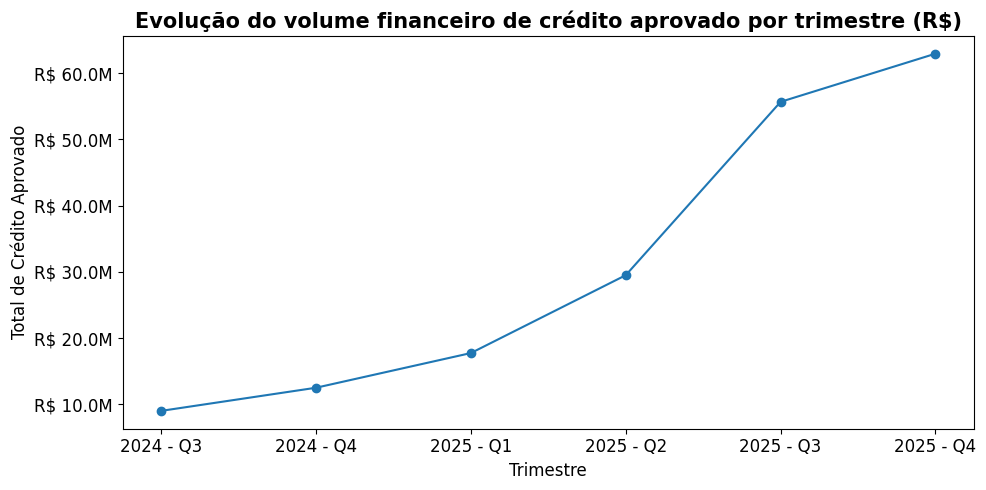

In [26]:
# visualizando a evolução do volume de crédito
credito_trimestre = total_credito_aprovado.reset_index()

credito_trimestre = credito_trimestre[
    credito_trimestre['approval_quarter'].between(
        pd.Period('2024Q3', freq='Q'),
        pd.Period('2025Q4', freq='Q')
    )
]

credito_trimestre['quarter'] = (
    credito_trimestre['approval_quarter']
    .astype(str)
    .str.replace('Q', ' - Q')
)

plt.figure(figsize=(10, 5))

plt.plot(
    range(len(credito_trimestre)),
    credito_trimestre['loan_amount'],
    marker='o'
)

plt.xticks(
    range(len(credito_trimestre)),
    credito_trimestre['quarter']
)

plt.gca().yaxis.set_major_formatter(
    mtick.FuncFormatter(lambda x, _: f'R$ {x/1_000_000:.1f}M')
)

plt.gca().tick_params(axis='both', labelsize=12)

plt.title(
    'Evolução do volume financeiro de crédito aprovado por trimestre (R$)',
    fontweight='bold',
    size=15
)

plt.xlabel('Trimestre', size=12)
plt.ylabel('Total de Crédito Aprovado', size=12)

plt.tight_layout()
plt.show()

#### Conclusão: O volume de crédito aprovado apresentou um grande crescimento ao longo do período analisado, passando de aproximadamente R$ 9 milhões no terceiro trimestre de 2024 para R$ 62,9 milhões no quarto trimestre de 2025, ou seja, quase 7 vezes mais que o valor no início do período. O crescimento se intensificou principalmente em 2025, com destaque para o período entre o segundo e quarto trimestre.

### 2. O crescimento do crédito aprovado foi acompanhado pelo crescimento das operações fechadas?

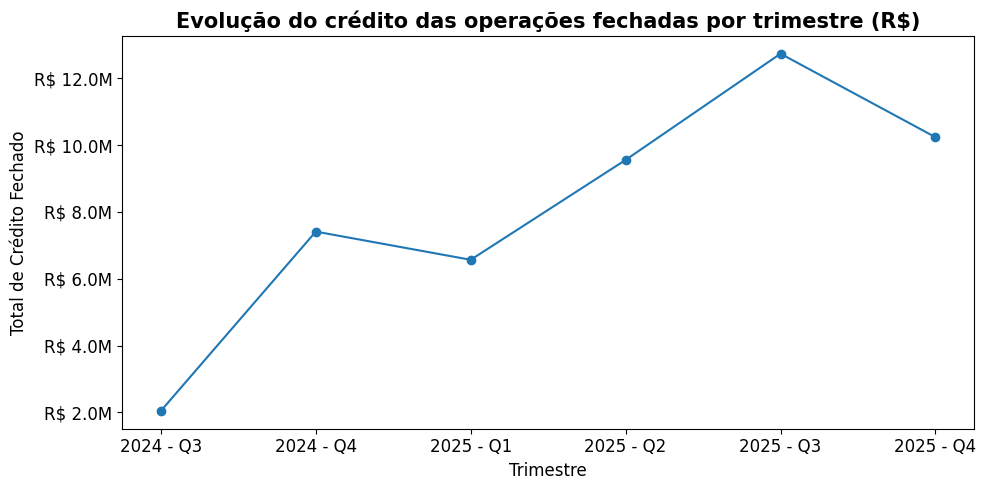

In [27]:
# visualizando a evolução das operações fechadas
operacoes_fechadas_trimestre = credito_operacoes_fechadas.reset_index()

operacoes_fechadas_trimestre = operacoes_fechadas_trimestre[
    operacoes_fechadas_trimestre['closed_at'].between(
        pd.Period('2024Q3', freq='Q'),
        pd.Period('2025Q4', freq='Q')
    )
]

operacoes_fechadas_trimestre['quarter'] = (
    operacoes_fechadas_trimestre['closed_at']
    .astype(str)
    .str.replace('Q', ' - Q')
)

plt.figure(figsize=(10, 5))

plt.plot(
    range(len(operacoes_fechadas_trimestre)),
    operacoes_fechadas_trimestre['loan_amount'],
    marker='o'
)

plt.xticks(
    range(len(operacoes_fechadas_trimestre)),
    operacoes_fechadas_trimestre['quarter']
)

plt.gca().yaxis.set_major_formatter(
    mtick.FuncFormatter(lambda x, _: f'R$ {x/1_000_000:.1f}M')
)

plt.gca().tick_params(axis='both', labelsize=12)

plt.title(
    'Evolução do crédito das operações fechadas por trimestre (R$)',
    fontweight='bold',
    size=15
)

plt.xlabel('Trimestre', size=12)
plt.ylabel('Total de Crédito Fechado', size=12)

plt.tight_layout()
plt.show()

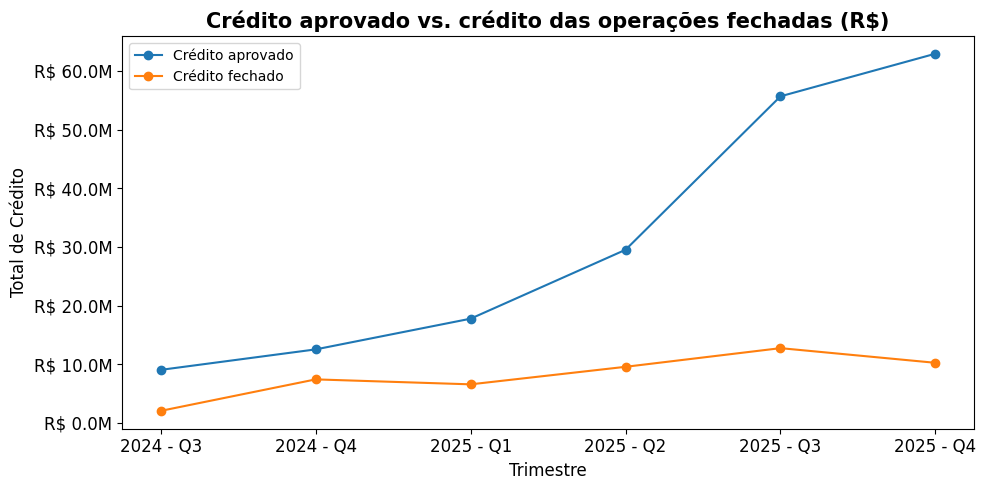

In [28]:
# crédito aprovadao vs crédito fechado
plt.figure(figsize=(10, 5))

plt.plot(
    range(len(credito_trimestre)),
    credito_trimestre['loan_amount'],
    marker='o',
    label='Crédito aprovado'
)

plt.plot(
    range(len(operacoes_fechadas_trimestre)),
    operacoes_fechadas_trimestre['loan_amount'],
    marker='o',
    label='Crédito fechado'
)

plt.xticks(
    range(len(credito_trimestre)),
    credito_trimestre['quarter']
)

plt.gca().yaxis.set_major_formatter(
    mtick.FuncFormatter(lambda x, _: f'R$ {x/1_000_000:.1f}M')
)

plt.gca().tick_params(axis='both', labelsize=12)

plt.title(
    'Crédito aprovado vs. crédito das operações fechadas (R$)',
    fontweight='bold',
    size=15
)

plt.xlabel('Trimestre', size=12)
plt.ylabel('Total de Crédito', size=12)

plt.legend()

plt.tight_layout()
plt.show()

#### Conclusão: Embora o percentual de crédito aprovado que chegou ao fechamento tenha apresentado redução ao longo do período, passando de 23% no Q3-2024 para 16% no Q4-2025, o crescimento do crédito aprovado também elevou o volume absoluto de crédito fechado, de aproximadamente R$ 2,0 milhões para R$ 10,2 milhões. O maior volume de crédito fechado ocorreu no Q3-2025, com aproximadamente R$ 12,7 milhões. Entretanto, no Q4-2025, enquanto o crédito aprovado continuou crescendo, o volume de crédito fechado diminuiu, indicando que o crescimento das aprovações não foi acompanhado na mesma proporção pelos fechamentos.

### 3. Quais tipos de imóvel concentram o maior volume de crédito aprovado?

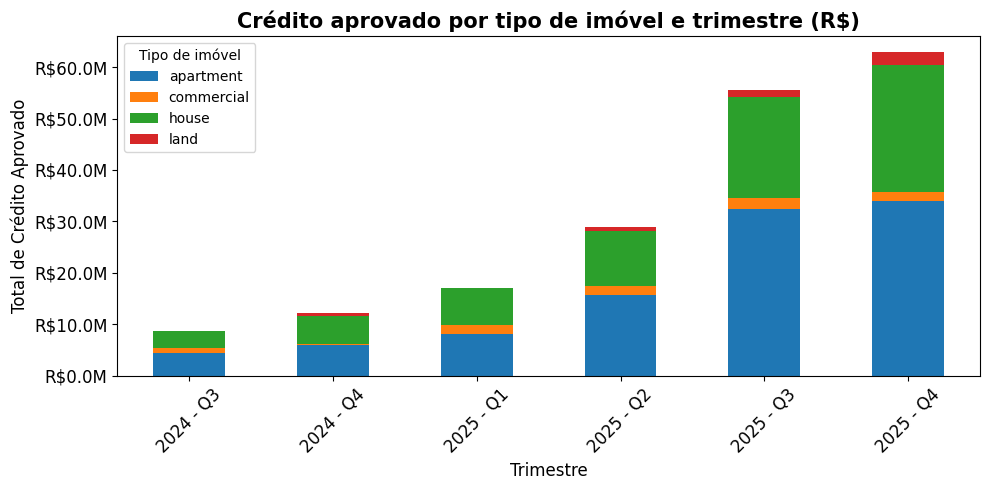

In [29]:
# visualizando volume de crédito por tipo de imóvel em cada trimestre
df_periodo_imovel = df[
    (df['credit_approval'] >= '2024-07-01') &
    (df['credit_approval'] < '2026-01-01')
].copy()

credito_tipo_imovel = (
    df_periodo_imovel
    .groupby([
        df_periodo_imovel['credit_approval'].dt.to_period('Q'),
        'property_type'
    ])['loan_amount']
    .sum()
    .unstack(fill_value=0)
)

credito_tipo_imovel.index = (
    credito_tipo_imovel.index
    .astype(str)
    .str.replace('Q', ' - Q')
)

ax = credito_tipo_imovel.plot(
    kind='bar',
    stacked=True,
    figsize=(10, 5)
)

ax.set_title(
    'Crédito aprovado por tipo de imóvel e trimestre (R$)',
    fontweight='bold',
    size=15
)

ax.set_xlabel('Trimestre', size=12)
ax.set_ylabel('Total de Crédito Aprovado', size=12)

ax.tick_params(axis='both', labelsize=12)
plt.xticks(rotation=45)

ax.yaxis.set_major_formatter(
    mtick.FuncFormatter(lambda x, _: f'R${x/1_000_000:,.1f}M')
)

ax.legend(title='Tipo de imóvel')

plt.tight_layout()
plt.show()

#### Conclusão: O crédito aprovado esteve concentrado principalmente em apartamentos e casas ao longo de todo o período. Os apartamentos apresentaram o maior volume de crédito em todos os trimestres, com destaque para Q2-2025 a Q4-2025, enquanto as casas também representaram uma parcela significativa do total. Já os demais tipos de imóvel apresentaram participação reduzida. Além disso, o crescimento do crédito aprovado ao longo de 2025 ocorreu principalmente pelo aumento dos volumes destinados a apartamentos e casas.

### 4. Qual tipo de imóvel possui a maior percentual de fechamento?

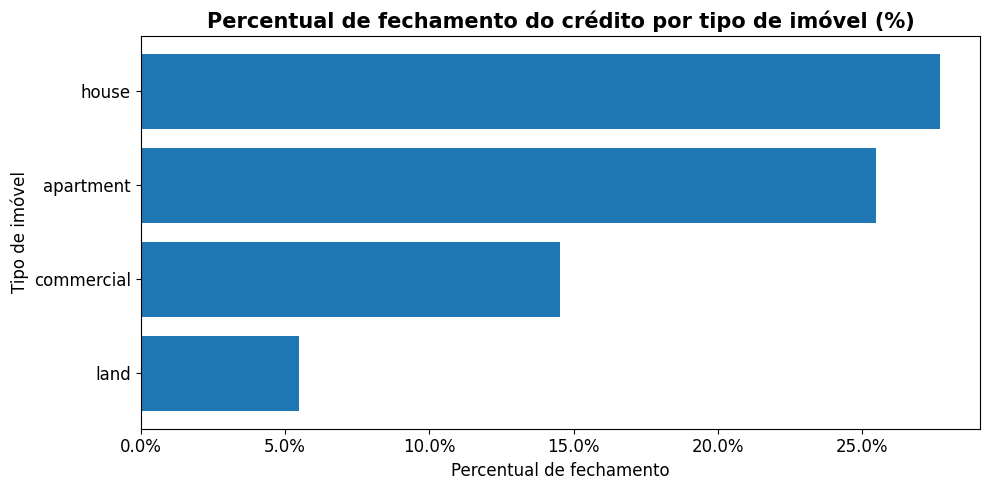

In [30]:
# visualizando percentual de fechamento por tipo de imóvel 
df_periodo = df[
    (df['credit_approval'] >= '2024-07-01') &
    (df['credit_approval'] < '2026-01-01')
].copy()

credito_aprovado_tipo = (
    df_periodo
    .groupby('property_type')['loan_amount']
    .sum()
)

credito_fechado_tipo = (
    df[
        df['closed_at'].notna() &
        (df['closed_at'] >= '2024-07-01') &
        (df['closed_at'] < '2026-01-01')
    ]
    .groupby('property_type')['loan_amount']
    .sum()
)

percentual_fechamento = (
    credito_fechado_tipo
    / credito_aprovado_tipo
    * 100
)

percentual_fechamento = (
    percentual_fechamento
    .reset_index(name='percentual_fechamento')
    .sort_values('percentual_fechamento', ascending=False)
)

plt.figure(figsize=(10, 5))

dados = percentual_fechamento.sort_values(
    'percentual_fechamento',
    ascending=True
)

plt.barh(
    dados['property_type'],
    dados['percentual_fechamento']
)

plt.title(
    'Percentual de fechamento do crédito por tipo de imóvel (%)',
    fontweight='bold',
    size=15
)

plt.xlabel('Percentual de fechamento', size=12)
plt.ylabel('Tipo de imóvel', size=12)

plt.gca().xaxis.set_major_formatter(
    mtick.PercentFormatter()
)

plt.gca().tick_params(axis='both', labelsize=12)

plt.tight_layout()
plt.show()

#### Conclusão: Apesar de os apartamentos concentrarem o maior volume de crédito aprovado, as casas apresentam um percentual de fechamento ligeiramente superior, de 27,70% contra 25,48% dos apartamentos. Já os imóveis comerciais e terrenos apresentam percentuais de fechamento consideravelmente menores, indicando diferenças no comportamento de fechamento entre os tipos de imóvel.

### 5. A quantidade de Dados Ausentes Diminuiu ao Longo do Tempo?

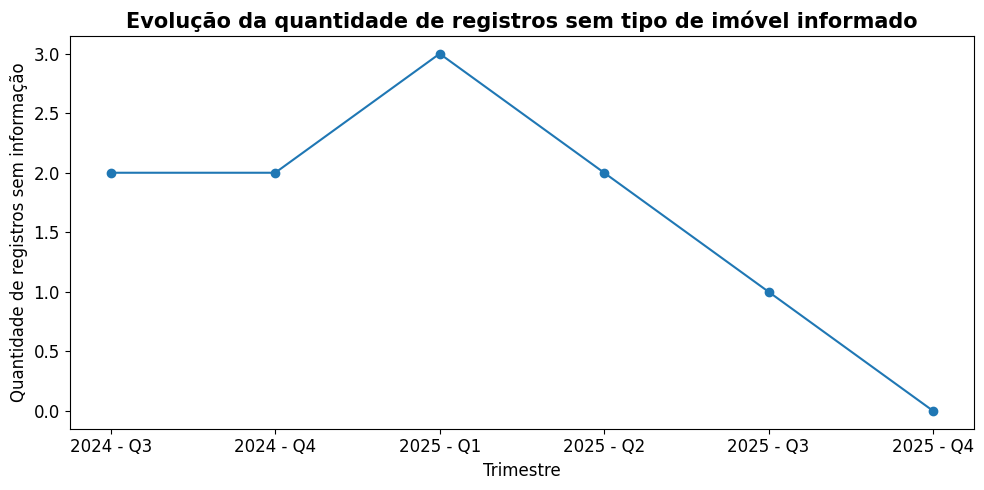

In [31]:
# visualizando a quantidade de dados ausentes ao longo do período
df_periodo = df[
    (df['credit_approval'] >= '2024-07-01') &
    (df['credit_approval'] < '2026-01-01')
].copy()

nulos_tipo_imovel = (
    df_periodo
    .groupby(
        df_periodo['credit_approval'].dt.to_period('Q')
    )['property_type']
    .apply(lambda x: x.isna().sum())
    .reset_index(name='quantidade_nulos')
)

nulos_tipo_imovel['quarter'] = (
    nulos_tipo_imovel['credit_approval']
    .astype(str)
    .str.replace('Q', ' - Q')
)

plt.figure(figsize=(10, 5))

plt.plot(
    nulos_tipo_imovel['quarter'],
    nulos_tipo_imovel['quantidade_nulos'],
    marker='o'
)

plt.title(
    'Evolução da quantidade de registros sem tipo de imóvel informado',
    fontweight='bold',
    size=15
)

plt.xlabel('Trimestre', size=12)
plt.ylabel('Quantidade de registros sem informação', size=12)

plt.gca().tick_params(axis='both', labelsize=12)

plt.tight_layout()
plt.show()

#### Conclusão: A quantidade de registros sem informação sobre o tipo de imóvel apresentou uma pequena alta no Q1-2025. A partir desse período, houve uma redução contínua, chegando a zero no Q4-2025, indicando uma melhora na completude dos dados referentes ao tipo de imóvel ao longo do período analisado.

### 6. Qual o canal mais relevante em termos de volume?

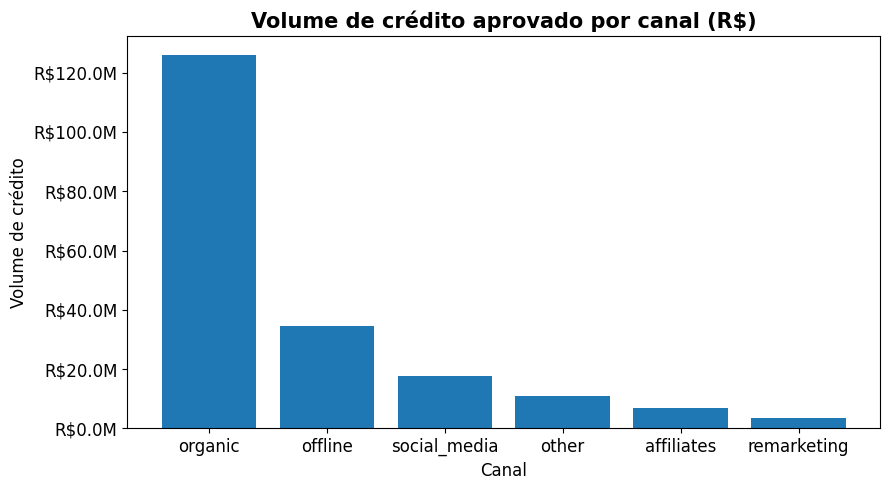

In [32]:
# visualizando o volume de crédito por canal 
credito_por_canal = (
    df.groupby('channel')['loan_amount']
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(9, 5))

plt.bar(
    credito_por_canal.index,
    credito_por_canal
)

plt.title(
    'Volume de crédito aprovado por canal (R$)',
    fontweight='bold',
    size=15
)

plt.xlabel('Canal', size=12)
plt.ylabel('Volume de crédito', size=12)

plt.gca().yaxis.set_major_formatter(
    mtick.FuncFormatter(lambda x, _: f'R${x/1_000_000:,.1f}M')
)

plt.gca().tick_params(axis='both', labelsize=12)

plt.tight_layout()
plt.show()

#### Conclusão: O canal Organic foi o mais relevante em termos de volume financeiro, movimentando aproximadamente R$ 126,1 milhões em crédito. Esse valor representa uma diferença expressiva em relação ao segundo maior canal, Offline, com aproximadamente R$ 34,7 milhões. Os demais canais apresentaram volumes significativamente menores.

### 7. Qual o Canal Mais Relevante em Termos de Conversão?

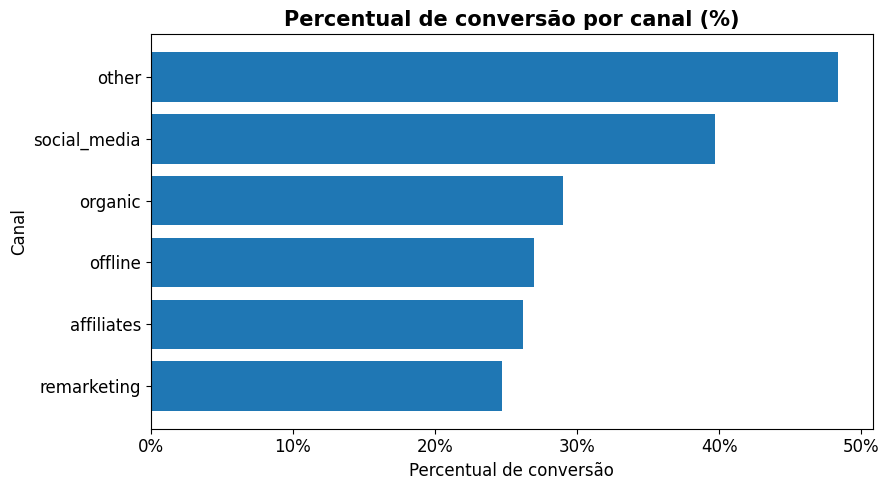

In [33]:
# visualizando a conversão de crédito por canal 
credito_aprovado_canal = (
    df.groupby('channel')['loan_amount']
    .sum()
)

credito_fechado_canal = (
    df[df['closed_at'].notna()]
    .groupby('channel')['loan_amount']
    .sum()
)

conversao_canal = (
    credito_fechado_canal
    / credito_aprovado_canal
    * 100
)

conversao_canal = (
    conversao_canal
    .sort_values(ascending=False)
)

plt.figure(figsize=(9, 5))

dados = conversao_canal.sort_values(ascending=True)

plt.barh(
    dados.index,
    dados.values
)

plt.title(
    'Percentual de conversão por canal (%)',
    fontweight='bold',
    size=15
)

plt.xlabel('Percentual de conversão', size=12)
plt.ylabel('Canal', size=12)

plt.gca().xaxis.set_major_formatter(
    mtick.PercentFormatter()
)

plt.gca().tick_params(axis='both', labelsize=12)

plt.tight_layout()
plt.show()

#### Conclusão: Em termos de conversão financeira, o canal Other apresentou o maior percentual, com 48,37%, seguido por Social Media, com 39,67%. Já Remarketing apresentou o menor percentual, com 24,71%. Isso mostra que os canais apresentam diferenças relevantes entre o volume financeiro gerado e a proporção desse volume que chegou ao fechamento.